<a href="https://colab.research.google.com/github/KANISHKA-EEE/kanishka-codeboosters-2026/blob/main/Day_2/Day_2_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraries imported successfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [ ]:
df=pd.read_csv('/content/student_performance.csv')
print(f"Dataset loaded:{df.shape[0]} students,{df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 row:")
print(df)
df.head(5)

Dataset loaded:30 students,13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 row:
    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9  

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [ ]:
conn=sqlite3.connect('collegestudent.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Database college.db created successfully")
print(f"Number of Rows: {count}")

Database college.db created successfully
Number of Rows: 30


In [ ]:
def run_query(sql, description="student"):
    if description:
        print(description)
    result = pd.read_sql_query(sql, conn)
    print(result.to_string(index=False))
    return result
print("Helper function 'run_query' defined successfully!")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully!
Usage: run_query(sql_string, description_label)


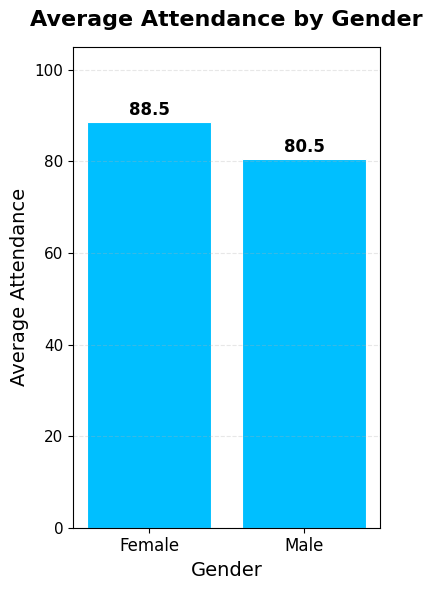

In [ ]:
#get data using sql
chart1_sql="""
SELECT gender,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig, ax=plt.subplots(figsize=(4,6))
bar_colors=['#00BFFF', '#00BFFF']
bars=ax.bar(
    chart1_data['gender'],
    chart1_data['avg_attendance'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)
for bar in bars:
    height=bar.get_height()
    ax.text(
        bar.get_x()+bar.get_width()/2,
        height+0.8,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='black'
    )
ax.set_title(
    "Average Attendance by Gender",
    fontsize=16,
    fontweight='bold',
    pad=15
)
ax.set_xlabel("Gender", fontsize=14)
ax.set_ylabel("Average Attendance", fontsize=14)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

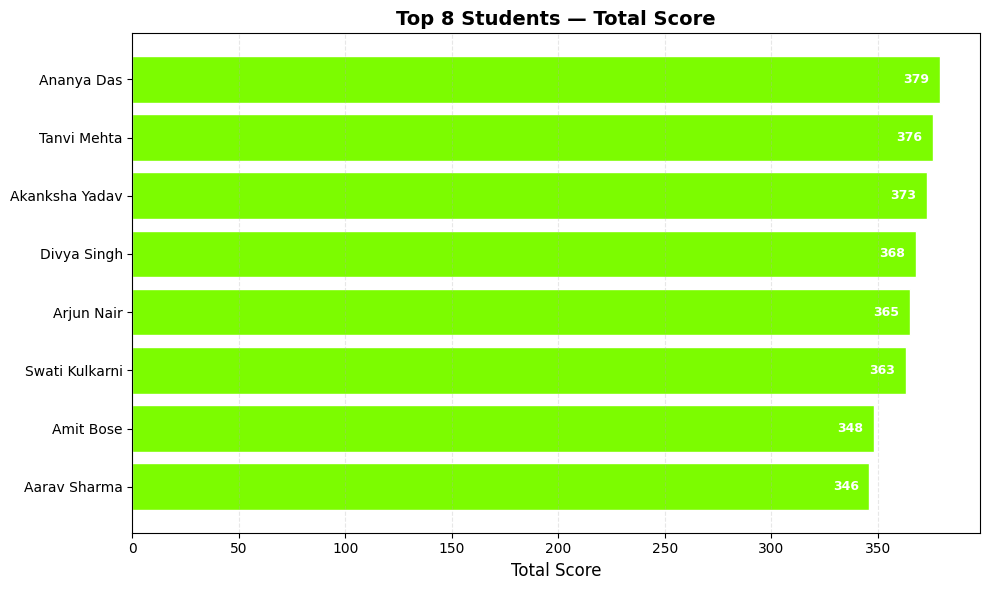

In [ ]:
#get data using sql
chart3_sql="""
SELECT
name,
(math_score + science_score + programming_score + attendance_percentage) AS total_marks
FROM students
ORDER BY total_marks DESC
LIMIT 8
"""
chart3_data=pd.read_sql_query(chart3_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=['#7CFC00']*8
bars=ax.barh(
    chart3_data['name'],
    chart3_data['total_marks'],
    color=bar_colors,
    edgecolor='white',
    linewidth=1
)
ax.invert_yaxis()
for bar in bars:
    width=bar.get_width()
    ax.text(
        width-5,
        bar.get_y()+bar.get_height()/2,
        f"{int(width)}",
        ha='right',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='white'
    )

ax.set_title(
    "Top 8 Students — Total Score",
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel("Total Score",fontsize=12)
ax.grid(axis='x',linestyle='--',alpha=0.3)
plt.tight_layout()
plt.show()

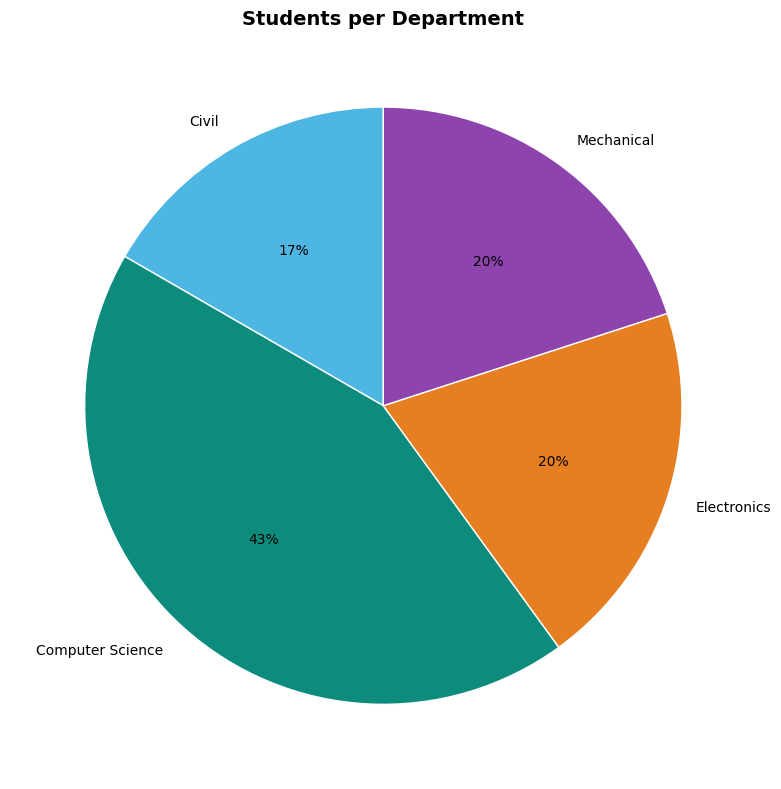

In [ ]:
#get data using sql
chart2_sql="""
SELECT department,
COUNT(*) AS total_students
FROM students
GROUP BY department
"""
chart2_data=pd.read_sql_query(chart2_sql,conn)
fig,ax=plt.subplots(figsize=(8,8))
pie_colors=['#4DB6E2','#0D8C7D','#E67E22','#8E44AD']
ax.pie(
    chart2_data['total_students'],labels=chart2_data['department'],
    autopct='%1.0f%%',
    startangle=90,
    colors=pie_colors,
    wedgeprops={'edgecolor':'white','linewidth':1}
)
ax.set_title(
    "Students per Department",
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()